In [1]:
import sys
sys.path.append('/global/homes/c/cpopik/')
from Basics import *
setplot(dark=True)

from HODModels import Kou2023, More2015, Yuan2023, Linke2022

[Text(0.5, 0, '$\\text{Mpc}$')]

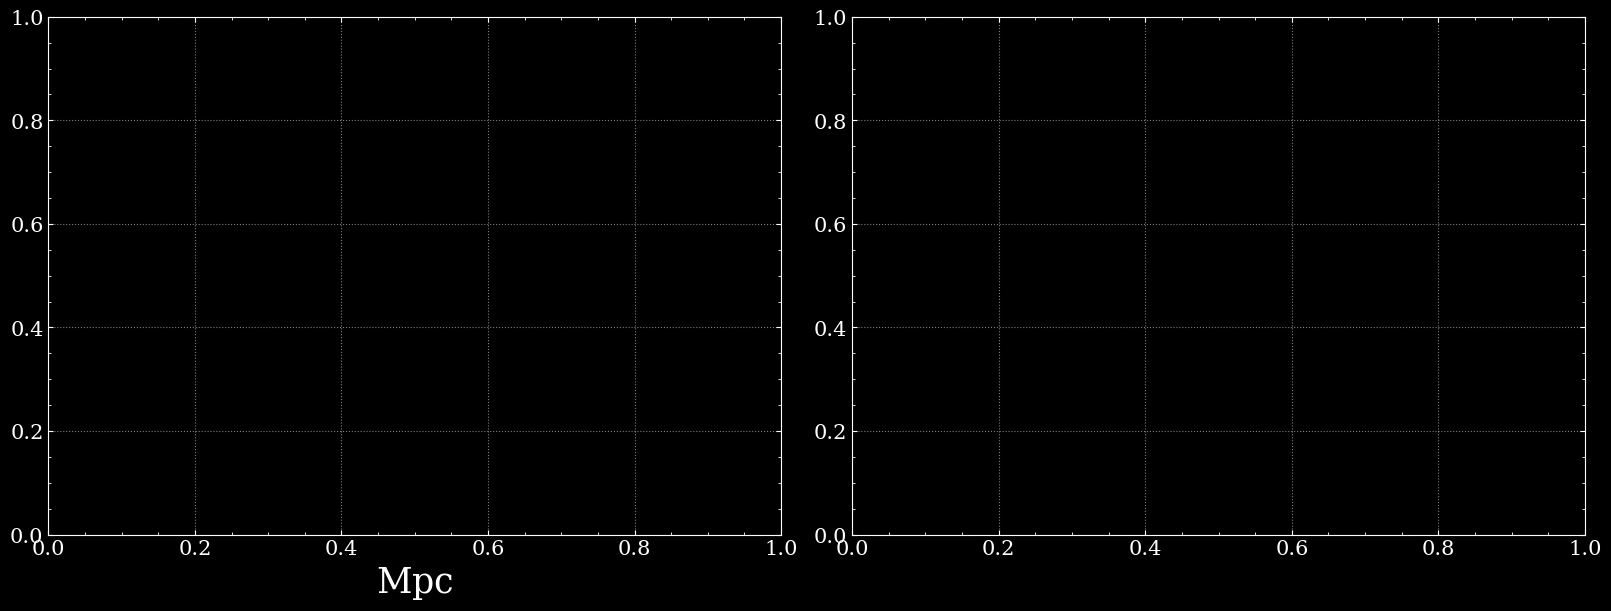

In [2]:
fig, axs = plt.subplots(1,2, figsize=(16, 6), layout='constrained')
axs[0].set(xlabel=r'$\text{Mpc}$')

In [2]:
def makeplot():
    fig, gs = plt.figure(figsize=(6, 5)), mpl.gridspec.GridSpec(2, 1, height_ratios=[3, 1])
    fig.subplots_adjust(hspace=0, wspace=0, bottom=0.2, left=0.2)

    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1], sharex=ax1)

    ax1.set(xscale='log', ylim=[-0.1, 2])
    ax1.set_ylabel(r"$ \overline{N}_\text{gal}$", fontsize=20)
    ax2.set_xlabel(r"$M_h$ [M$_\odot$]", fontsize=20)
    ax2.set(ylim=[-1.2, 1.2]); 
    ax2.set_ylabel(r"$\Delta \overline{N}$", fontsize=15); ax2.tick_params(axis='y', labelsize=10)
    # ax2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter('{0:.0%}'.format))

    ax1.fill_betweenx([-2, 3], 10**12.12, 10**13.98, color='yellow', alpha=0.15)
    ax2.fill_betweenx([-2, 3], 10**12.12, 10**13.98, color='yellow', alpha=0.15)
    return fig, ax1, ax2

# Kou

In [3]:
koukeys = ['logM_min', 'sigma_logM', 'logM_1', 'beta_s', '1-b_h', 'A', 'alpha_inc', 'logM_inc']
kouchains = {}
for j in range(4):
    f = h5py.File(f"/pscratch/sd/c/cpopik/Chains/Kou2023Chains/bin_{j}.h5", 'r')
    kouchains[f"Bin{j}"] = {}
    for i in range(f['mcmc']['chain'].shape[-1]):
        kouchains[f"Bin{j}"][koukeys[i]] = f['mcmc']['chain'][:, :, i]


pvalues = {}
for i in range(4):
    pvalues[f'Bin{i}'] = {}
    for pname in koukeys: 
        pvalues[f'Bin{i}'][pname] = {'med': np.percentile(kouchains[f'Bin{i}'][pname][5000:, :], 50),
                        'lowerr': np.percentile(kouchains[f'Bin{i}'][pname][5000:, :], 16),
                        'uperr': np.percentile(kouchains[f'Bin{i}'][pname][5000:, :], 84),
                        'min': np.percentile(kouchains[f'Bin{i}'][pname][5000:, :], 0),
                        'max': np.percentile(kouchains[f'Bin{i}'][pname][5000:, :], 100)}

In [4]:
Ms = np.geomspace(5e11, 2e15, 1000)

nsstest, ncstest = [], []
for i in range(150):
    # for j in range(5000, 8000):
    for j in range(7999, 8000):
        overridedict={}
        for pname in koukeys: overridedict[pname] = kouchains['Bin0'][pname][j, i]
        model = Kou2023(Ms, "A", override=overridedict)
        nsstest.append(model.Ns())
        ncstest.append(model.Nc())

Ncvalues, Nsvalues, Nvalues = np.array(ncstest), np.array(nsstest), np.array(ncstest)+np.array(nsstest)

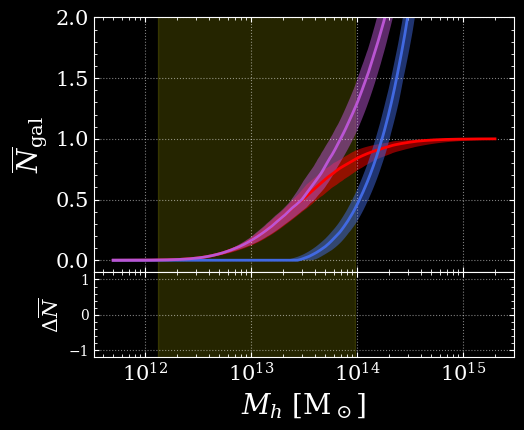

In [5]:
fig, ax1, ax2 = makeplot()

ax1.plot(Ms, np.percentile(Ncvalues, 50, axis=0), lw=2, c='r')
ax1.fill_between(Ms, np.percentile(Ncvalues, 16, axis=0), np.percentile(Ncvalues, 84, axis=0), alpha=0.5, color='r', lw=0)

ax1.plot(Ms, np.percentile(Nsvalues, 50, axis=0), lw=2, c='royalblue')
ax1.fill_between(Ms, np.percentile(Nsvalues, 16, axis=0), np.percentile(Nsvalues, 84, axis=0), alpha=0.5, color='royalblue', lw=0)

ax1.plot(Ms, np.percentile(Nvalues, 50, axis=0), lw=2, c='mediumorchid')
ax1.fill_between(Ms, np.percentile(Nvalues, 16, axis=0), np.percentile(Nvalues, 84, axis=0), alpha=0.5, color='mediumorchid', lw=0)

fig.savefig("/global/homes/c/cpopik/Git/Capybara/Figures/layouttest.png")

In [9]:
param, pprint = 'sigma_logM', r"$\sigma_{\log M}$"
pfidi = Kou2023(Ms, "A").Params[param]['A']
nframes = 100
pframes = np.linspace(pvalues['Bin0'][param]['min'], pvalues['Bin0'][param]['max'], int(nframes/2)+1)
pframes = np.concatenate([pframes[:-1], pframes[::-1][:-1]])

Ncsframes, Nssframes = [], []
fidiNcs, fidiNss, fidiNs = Kou2023(Ms, "A").Nc(), Kou2023(Ms, "A").Ns(), Kou2023(Ms, "A").N()
for i in range(pframes.size):
    model = Kou2023(Ms, "A", override={param: pframes[i]})
    Ncsframes.append(model.Nc())
    Nssframes.append(model.Ns())
Ncsframes, Nssframes, Nsframes = np.array(Ncsframes), np.array(Nssframes), np.array(Ncsframes)+np.array(Nssframes)

NcFframes = np.array([(Ncsframes[i]-fidiNcs)/1 for i in range(Ncsframes.shape[0])])
NsFframes = np.array([(Nssframes[i]-fidiNss)/1 for i in range(Ncsframes.shape[0])])
NFframes = np.array([(Nsframes[i]-fidiNs)/1 for i in range(Ncsframes.shape[0])])
# for i in range(Nssframes.shape[0]): 
#     NsFframes[i][(Nssframes[i]==0) & (fidiNss==0)] = 0
#     NsFframes[i][(Nssframes[i]==0) & (fidiNss==0)] = 0

In [10]:
def update(frame):
    ax1.set_title(pprint+f"={pframes[frame]:.2f}", fontsize=20), ax1.legend()
    Nsline.set_ydata(Nsframes[frame]), Ncsline.set_ydata(Ncsframes[frame]), Nssline.set_ydata(Nssframes[frame])
    Nsline.set_ydata(Nsframes[frame]), Ncsline.set_ydata(Ncsframes[frame]), Nssline.set_ydata(Nssframes[frame])
    Nfline.set_ydata(NFframes[frame]), Ncfline.set_ydata(NcFframes[frame]), Nsfline.set_ydata(NsFframes[frame])
    return Ncsline, Nssline, Nsline, Nfline

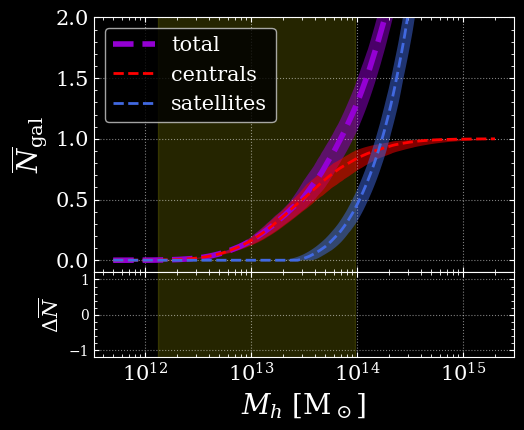

In [17]:
fig, ax1, ax2 = makeplot()

ax1.fill_between(Ms, np.percentile(Nvalues, 16, axis=0), np.percentile(Nvalues, 84, axis=0), alpha=0.5, color='darkviolet', lw=0)
ax1.fill_between(Ms, np.percentile(Ncvalues, 16, axis=0), np.percentile(Ncvalues, 84, axis=0), alpha=0.5, color='r', lw=0)
ax1.fill_between(Ms, np.percentile(Nsvalues, 16, axis=0), np.percentile(Nsvalues, 84, axis=0), alpha=0.5, color='royalblue', lw=0)

ax1.plot(Ms, np.percentile(Nvalues, 50, axis=0), lw=4, c='darkviolet', ls='--', label=r"total")
ax1.plot(Ms, np.percentile(Ncvalues, 50, axis=0), lw=2, c='r', ls='--',label=r"centrals")
ax1.plot(Ms, np.percentile(Nsvalues, 50, axis=0), lw=2, c='royalblue', ls='--', label=r"satellites")


# Nsline = ax1.plot(Ms, Nsframes[0], c="violet", lw=4)[0]
# Ncsline = ax1.plot(Ms, Ncsframes[0], c="coral", lw=2)[0]
# Nssline = ax1.plot(Ms, Nssframes[0], c="skyblue", lw=2)[0]
# ax1.set_title(pprint+f"={pframes[0]:.2f}", fontsize=20)

# Nfline = ax2.plot(Ms, NFframes[0], c="violet", lw=4)[0]
# Ncfline = ax2.plot(Ms, NcFframes[0], c="coral", lw=2)[0]
# Nsfline = ax2.plot(Ms, NsFframes[0], c="skyblue", lw=2)[0]

# update(25)

ax1.legend(); plt.show()

In [12]:
ani = mpl.animation.FuncAnimation(fig=fig, func=update, frames=nframes, interval=10)
ani.save(filename="/global/homes/c/cpopik/Git/Capybara/Figures/HODsigmaM.gif", writer="pillow")

In [ ]:
hcosnhzm = np.array([1.114e-15, 9.359e-16, 7.888e-16, 6.647e-16, 5.600e-16, 4.716e-16, 3.971e-16, 3.343e-16, 2.814e-16, 2.367e-16, 
                1.991e-16, 1.674e-16, 1.407e-16, 1.182e-16, 9.930e-17, 8.336e-17, 7.000e-17, 5.868e-17, 4.919e-17, 4.122e-17, 
                3.452e-17, 2.889e-17, 2.417e-17, 2.020e-17, 1.688e-17, 1.409e-17, 1.175e-17, 9.795e-18, 8.157e-18, 6.787e-18, 
                5.642e-18, 4.685e-18, 3.887e-18, 3.220e-18, 2.665e-18, 2.203e-18, 1.819e-18, 1.500e-18, 1.234e-18, 1.015e-18, 
                8.325e-19, 6.820e-19, 5.576e-19, 4.551e-19, 3.706e-19, 3.012e-19, 2.442e-19, 1.975e-19, 1.587e-19])

hcosms = np.array([1.318e+12, 1.441e+12, 1.576e+12, 1.723e+12, 1.884e+12, 2.059e+12, 2.252e+12, 2.462e+12, 2.692e+12, 2.943e+12, 
                   3.217e+12, 3.518e+12, 3.846e+12, 4.205e+12, 4.597e+12, 5.026e+12, 5.495e+12, 6.008e+12, 6.569e+12, 7.182e+12, 
                   7.852e+12, 8.585e+12, 9.386e+12, 1.026e+13, 1.122e+13, 1.227e+13, 1.341e+13, 1.466e+13, 1.603e+13, 1.753e+13, 
                   1.916e+13, 2.095e+13, 2.291e+13, 2.505e+13, 2.738e+13, 2.994e+13, 3.273e+13, 3.579e+13, 3.913e+13, 4.278e+13, 
                   4.677e+13, 5.114e+13, 5.591e+13, 6.113e+13, 6.683e+13, 7.307e+13, 7.989e+13, 8.735e+13, 9.550e+13])

# Kou 2023

In [9]:
M_Kou2023 = np.array([1.01E+12,1.24E+12,1.59E+12,2.24E+12,3.15E+12,4.42E+12,6.42E+12,
                     9.51E+12,1.44E+13,2.10E+13,3.43E+13,5.28E+13,7.92E+13,1.11E+14,
                     1.77E+14,2.66E+14,3.81E+14,5.74E+14,8.66E+14,1.25E+15,1.96E+15])
    
NM_A_Kou2023 = np.array([2.33E-03,3.85E-03,6.89E-03,1.48E-02,2.96E-02,5.47E-02,1.01E-01,
                     1.77E-01,2.80E-01,3.94E-01,5.65E-01,8.12E-01,1.09E+00,1.39E+00,
                     1.95E+00,2.65E+00,3.65E+00,5.12E+00,7.44E+00,1.04E+01,1.58E+01])

NM_B_Kou2023 = np.array([1.77E-03,2.96E-03,5.35E-03,1.12E-02,2.28E-02,4.30E-02,7.94E-02,
                     1.39E-01,2.30E-01,3.27E-01,4.74E-01,6.81E-01,9.47E-01,1.26E+00,
                     1.83E+00,2.54E+00,3.49E+00,4.96E+00,7.20E+00,1.02E+01,1.57E+01])

NM_C_Kou2023 = np.array([1.07E-03,1.79E-03,3.13E-03,6.38E-03,1.29E-02,2.38E-02,4.35E-02,
                     7.86E-02,1.33E-01,2.00E-01,3.16E-01,4.35E-01,5.91E-01,8.39E-01,
                     1.33E+00,1.95E+00,2.80E+00,4.07E+00,6.24E+00,8.96E+00,1.40E+01])

NM_D_Kou2023 = np.array([5.84E-04,9.16E-04,1.55E-03,3.13E-03,6.04E-03,1.10E-02,2.04E-02,
                     3.69E-02,6.52E-02,1.02E-01,1.69E-01,2.48E-01,3.38E-01,4.25E-01,
                     6.24E-01,1.17E+00,2.02E+00,3.49E+00,5.91E+00,9.06E+00,1.44E+01])

[1000000000000.0, 1778279410038922.8, 0.0005, 30.0]


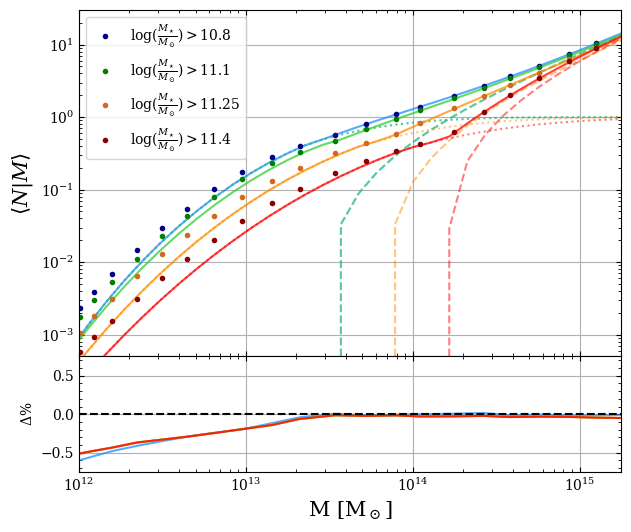

In [18]:
fig, gs = plt.figure(figsize=(7, 6)), gridspec.GridSpec(2, 1, height_ratios=[3, 1])
plt.tight_layout(), fig.subplots_adjust(hspace=0, wspace=0.25)
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1], sharex=ax1)
ax1.grid(); ax1.minorticks_on(), ax1.tick_params(direction='in', which='both', right=True, top=True, labelbottom=False)
ax2.grid(); ax2.minorticks_on(), ax2.tick_params(direction='in', which='both', right=True, top=True)

Ms = np.geomspace(1e10, 2e15)
ax1.loglog(Ms, Kou2023(Ms, "A").N(), c='dodgerblue', alpha=0.75), ax1.loglog(Ms, Kou2023(Ms, "A").Ns(), c='dodgerblue', ls='--', alpha=0.5), ax1.loglog(Ms, Kou2023(Ms, "A").Nc(), c='dodgerblue', ls=':', alpha=0.5)
ax1.loglog(Ms, Kou2023(Ms, "B").N(), c='limegreen', alpha=0.75), ax1.loglog(Ms, Kou2023(Ms, "A").Ns(), c='limegreen', ls='--', alpha=0.5), ax1.loglog(Ms, Kou2023(Ms, "A").Nc(), c='limegreen', ls=':', alpha=0.5)
ax1.loglog(Ms, Kou2023(Ms, "C").N(), c='darkorange', alpha=0.75), ax1.loglog(Ms, Kou2023(Ms, "C").Ns(), c='darkorange', ls='--', alpha=0.5), ax1.loglog(Ms, Kou2023(Ms, "C").Nc(), c='darkorange', ls=':', alpha=0.5)
ax1.loglog(Ms, Kou2023(Ms, "D").N(), c='r', alpha=0.75), ax1.loglog(Ms, Kou2023(Ms, "D").Ns(), c='r', ls='--', alpha=0.5), ax1.loglog(Ms, Kou2023(Ms, "D").Nc(), c='r', ls=':', alpha=0.5)

ax1.loglog(M_Kou2023, NM_A_Kou2023, c='darkblue', marker='.', lw=0, label=r'$\log(\frac{M_\star}{M_\odot})>10.8$')
ax1.loglog(M_Kou2023, NM_B_Kou2023, c='green', marker='.', lw=0, label=r'$\log(\frac{M_\star}{M_\odot})>11.1$')
ax1.loglog(M_Kou2023, NM_C_Kou2023, c='chocolate', marker='.', lw=0, label=r'$\log(\frac{M_\star}{M_\odot})>11.25$')
ax1.loglog(M_Kou2023, NM_D_Kou2023, c='darkred', marker='.', lw=0, label=r'$\log(\frac{M_\star}{M_\odot})>11.4$')

ax2.plot(M_Kou2023, (Kou2023(M_Kou2023, "A").N()-NM_A_Kou2023)/NM_A_Kou2023, c='dodgerblue', alpha=0.75)
ax2.plot(M_Kou2023, (Kou2023(M_Kou2023, "B").N()-NM_B_Kou2023)/NM_B_Kou2023, c='limegreen', alpha=0.75)
ax2.plot(M_Kou2023, (Kou2023(M_Kou2023, "B").N()-NM_B_Kou2023)/NM_B_Kou2023, c='darkorange', alpha=0.75)
ax2.plot(M_Kou2023, (Kou2023(M_Kou2023, "B").N()-NM_B_Kou2023)/NM_B_Kou2023, c='r', alpha=0.75)

ax2.set_xlabel(r'M [M$_\odot$]', size=15), ax2.set_xlim(1e12, 10**15.25)
ax1.set_ylabel(r'$ \langle N | M \rangle $', fontsize=15), ax1.set_ylim(5e-4, 3e1) 
ax2.set_ylabel(r"$\Delta \%$", fontsize=10), ax2.set_ylim(-0.75, 0.75), ax2.axhline(0, ls='--', c='k')

print([*ax1.get_xlim(), *ax1.get_ylim()])
ax1.legend(fontsize=10); plt.show()

# Linke 2022

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


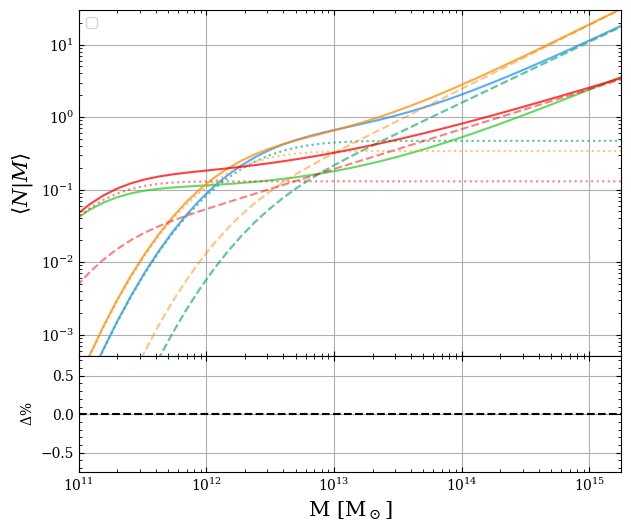

In [2]:
fig, gs = plt.figure(figsize=(7, 6)), gridspec.GridSpec(2, 1, height_ratios=[3, 1])
plt.tight_layout(), fig.subplots_adjust(hspace=0, wspace=0.25)
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1], sharex=ax1)
ax1.grid(); ax1.minorticks_on(), ax1.tick_params(direction='in', which='both', right=True, top=True, labelbottom=False)
ax2.grid(); ax2.minorticks_on(), ax2.tick_params(direction='in', which='both', right=True, top=True)

Ms = np.geomspace(1e10, 2e15)
ax1.loglog(Ms, Linke2022(Ms, "A").N(), c='dodgerblue', alpha=0.75), ax1.loglog(Ms, Linke2022(Ms, "A").Ns(), c='dodgerblue', ls='--', alpha=0.5), ax1.loglog(Ms, Linke2022(Ms, "A").Nc(), c='dodgerblue', ls=':', alpha=0.5)
ax1.loglog(Ms, Linke2022(Ms, "B").N(), c='limegreen', alpha=0.75), ax1.loglog(Ms, Linke2022(Ms, "A").Ns(), c='limegreen', ls='--', alpha=0.5), ax1.loglog(Ms, Linke2022(Ms, "A").Nc(), c='limegreen', ls=':', alpha=0.5)
ax1.loglog(Ms, Linke2022(Ms, "C").N(), c='darkorange', alpha=0.75), ax1.loglog(Ms, Linke2022(Ms, "C").Ns(), c='darkorange', ls='--', alpha=0.5), ax1.loglog(Ms, Linke2022(Ms, "C").Nc(), c='darkorange', ls=':', alpha=0.5)
ax1.loglog(Ms, Linke2022(Ms, "D").N(), c='r', alpha=0.75), ax1.loglog(Ms, Linke2022(Ms, "D").Ns(), c='r', ls='--', alpha=0.5), ax1.loglog(Ms, Linke2022(Ms, "D").Nc(), c='r', ls=':', alpha=0.5)

# ax1.loglog(M_Kou2023, NM_A_Kou2023, c='darkblue', marker='.', lw=0, label=r'$\log(\frac{M_\star}{M_\odot})>10.8$')
# ax1.loglog(M_Kou2023, NM_B_Kou2023, c='green', marker='.', lw=0, label=r'$\log(\frac{M_\star}{M_\odot})>11.1$')
# ax1.loglog(M_Kou2023, NM_C_Kou2023, c='chocolate', marker='.', lw=0, label=r'$\log(\frac{M_\star}{M_\odot})>11.25$')
# ax1.loglog(M_Kou2023, NM_D_Kou2023, c='darkred', marker='.', lw=0, label=r'$\log(\frac{M_\star}{M_\odot})>11.4$')

# ax2.plot(M_Kou2023, (Kou2023(M_Kou2023, "A").N()-NM_A_Kou2023)/NM_A_Kou2023, c='dodgerblue', alpha=0.75)
# ax2.plot(M_Kou2023, (Kou2023(M_Kou2023, "B").N()-NM_B_Kou2023)/NM_B_Kou2023, c='limegreen', alpha=0.75)
# ax2.plot(M_Kou2023, (Kou2023(M_Kou2023, "B").N()-NM_B_Kou2023)/NM_B_Kou2023, c='darkorange', alpha=0.75)
# ax2.plot(M_Kou2023, (Kou2023(M_Kou2023, "B").N()-NM_B_Kou2023)/NM_B_Kou2023, c='r', alpha=0.75)

ax2.set_xlabel(r'M [M$_\odot$]', size=15), ax2.set_xlim(1e11, 10**15.25)
ax1.set_ylabel(r'$ \langle N | M \rangle $', fontsize=15), ax1.set_ylim(5e-4, 3e1) 
ax2.set_ylabel(r"$\Delta \%$", fontsize=10), ax2.set_ylim(-0.75, 0.75), ax2.axhline(0, ls='--', c='k')
ax1.legend(fontsize=10); plt.show()

# More 2015

In [4]:
Nctrueraw_x = np.array([5.91E+12, 6.51E+12, 7.28E+12, 8.18E+12, 9.27E+12, 1.06E+13,
                        1.21E+13, 1.42E+13, 1.69E+13, 2.07E+13, 2.58E+13, 3.38E+13,
                        4.55E+13, 6.38E+13, 9.14E+13, 1.32E+14, 1.90E+14, 2.76E+14,
                        3.99E+14, 5.79E+14, 8.35E+14, 1.21E+15, 1.76E+15, 2.42E+15])

Nctrueraw_y = np.array([1.01E-01, 1.23E-01, 1.50E-01, 1.83E-01, 2.20E-01, 2.69E-01,
                        3.22E-01, 3.91E-01, 4.68E-01, 5.58E-01, 6.56E-01, 7.56E-01,
                        8.48E-01, 9.23E-01, 9.62E-01, 9.89E-01, 9.92E-01, 1.00E+00,
                        1.00E+00, 1.00E+00, 1.00E+00, 1.00E+00, 1.00E+00, 1.00E+00])


Nstrueraw_x = np.array([2.56E+13, 2.90E+13, 3.26E+13, 3.72E+13, 4.24E+13, 4.91E+13,
                        5.67E+13, 6.65E+13, 7.80E+13, 9.33E+13, 1.10E+14, 1.32E+14,
                        1.58E+14, 1.90E+14, 2.29E+14, 2.76E+14, 3.33E+14, 4.01E+14,
                        4.87E+14, 5.87E+14, 1.04E+15, 1.27E+15, 1.51E+15, 1.84E+15])
    
Nstrueraw_y = np.array([1.00E-01, 1.22E-01, 1.48E-01, 1.80E-01, 2.17E-01, 2.63E-01,
                        3.17E-01, 3.83E-01, 4.61E-01, 5.56E-01, 6.61E-01, 7.91E-01,
                        9.48E-01, 1.14E+00, 1.35E+00, 1.62E+00, 1.93E+00, 2.30E+00,
                        2.75E+00, 3.26E+00, 5.56E+00, 6.63E+00, 7.88E+00, 9.40E+00])


Ncincraw_x = np.array([1.01E+13, 1.13E+13, 1.33E+13, 1.57E+13, 1.86E+13, 2.41E+13,
                        3.09E+13, 4.04E+13, 5.11E+13, 6.70E+13, 8.89E+13, 1.29E+14, 
                       1.93E+14, 2.82E+14, 5.15E+14, 7.74E+14, 1.22E+15, 1.88E+15, 
                       2.51E+15, 3.77E+14])
    
Ncincraw_y = np.array([1.02E-01, 1.20E-01, 1.52E-01, 1.90E-01, 2.32E-01, 2.99E-01,
                        3.62E-01, 4.25E-01, 4.77E-01, 5.27E-01, 5.69E-01, 6.17E-01, 
                       6.56E-01, 6.92E-01, 7.44E-01, 7.79E-01, 8.19E-01, 8.58E-01, 
                       8.81E-01, 7.16E-01])


Nsincraw_x = np.array([3.93E+13, 4.67E+13, 5.40E+13, 6.38E+13, 7.33E+13, 8.53E+13,
                        9.93E+13, 1.16E+14, 1.37E+14, 1.63E+14, 1.94E+14, 2.34E+14,
                        2.80E+14, 3.45E+14, 4.13E+14, 5.01E+14, 5.79E+14, 6.74E+14,
                        8.02E+14, 1.01E+15, 1.25E+15, 1.48E+15, 1.73E+15, 2.21E+15])
    
Nsincraw_y = np.array([1.02E-01, 1.32E-01, 1.61E-01, 2.03E-01, 2.45E-01, 2.94E-01,
                        3.53E-01, 4.27E-01, 5.13E-01, 6.24E-01, 7.53E-01, 9.26E-01,
                        1.13E+00, 1.41E+00, 1.70E+00, 2.08E+00, 2.42E+00, 2.85E+00,
                        3.43E+00, 4.33E+00, 5.37E+00, 6.43E+00, 7.61E+00, 9.77E+00])

fincraw_x = np.array([1.22E+12,1.44E+12,1.72E+12,2.05E+12,2.48E+12,2.98E+12,3.59E+12,
                      4.31E+12,5.24E+12,6.37E+12,7.74E+12,9.35E+12,1.14E+13,1.39E+13,
                      1.70E+13,2.08E+13,2.52E+13,3.09E+13,3.77E+13,4.64E+13,5.68E+13,
                      6.94E+13,8.48E+13,1.04E+14,1.28E+14,1.58E+14,1.92E+14,2.30E+14,
                      2.80E+14,3.44E+14,4.18E+14,5.18E+14,6.33E+14,7.65E+14,9.41E+14,
                      1.15E+15,1.38E+15,1.69E+15,2.04E+15,2.48E+15])
    
fincraw_y = np.array([2.16E-01,2.30E-01,2.46E-01,2.62E-01,2.78E-01,2.95E-01,3.10E-01,
                      3.27E-01,3.43E-01,3.61E-01,3.77E-01,3.94E-01,4.12E-01,4.27E-01,
                      4.47E-01,4.64E-01,4.81E-01,4.99E-01,5.17E-01,5.33E-01,5.53E-01,
                      5.70E-01,5.86E-01,6.04E-01,6.22E-01,6.40E-01,6.57E-01,6.75E-01,
                      6.91E-01,7.10E-01,7.27E-01,7.45E-01,7.63E-01,7.81E-01,8.00E-01,
                      8.16E-01,8.33E-01,8.50E-01,8.64E-01,8.82E-01])

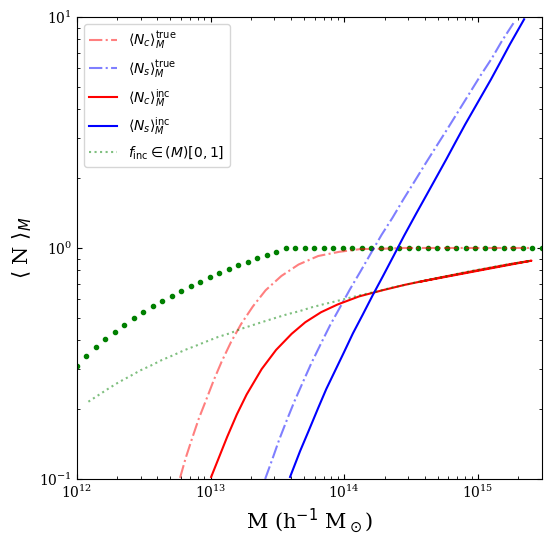

In [23]:
plt.figure(figsize=(6, 6))

plt.ylabel(r'$\langle$ N $\rangle_M$', fontsize=15), plt.ylim(1e-1, 1e1)


Ms = np.geomspace(1e12, 3e15)
plt.loglog(Ms, More2015(Ms, "A").f_inc(), lw=0, marker='.', c='g')

plt.loglog(Nctrueraw_x, Nctrueraw_y, c='r', ls='dashdot', alpha=0.5, label=r'$\langle N_c \rangle_M^{\text{true}}$')
plt.loglog(Nstrueraw_x, Nstrueraw_y, c='b', ls='dashdot', alpha=0.5, label=r'$\langle N_s \rangle_M^{\text{true}}$')
plt.loglog(Ncincraw_x, Ncincraw_y, c='r', label=r'$\langle N_c \rangle_M^{\text{inc}}$')
plt.loglog(Nsincraw_x, Nsincraw_y, c='b', label=r'$\langle N_s \rangle_M^{\text{inc}}$')
plt.loglog(fincraw_x, fincraw_y, c='g', ls=':', alpha=0.5, label=r'$f_{\text{inc}} \in (M) [0, 1]$')
plt.legend()

plt.xlabel(r'M (h$^{-1}$ M$_\odot$)', size=15), plt.xlim(1e12, 3*10**15)

plt.minorticks_on(), plt.tick_params(direction='in', which='both', right=True, top=True)
plt.show()

In [6]:
N1raw_x = np.array([1.19E+12, 1.37E+12, 1.54E+12, 1.79E+12, 2.06E+12, 2.37E+12, 2.76E+12, 3.20E+12,
                    3.71E+12, 4.64E+12, 5.89E+12, 7.81E+12, 1.01E+13, 1.35E+13, 1.79E+13, 2.38E+13,
                    3.34E+13, 4.84E+13, 7.12E+13, 1.05E+14, 1.50E+14, 2.10E+14, 2.96E+14, 4.35E+14,
                    6.50E+14, 8.75E+14, 1.19E+15, 1.71E+15, 2.46E+15])
                    
N1raw_y = np.array([1.05E-02, 1.51E-02, 2.10E-02, 2.97E-02, 4.22E-02, 5.77E-02, 7.77E-02, 1.03E-01,
                    1.35E-01, 1.94E-01, 2.68E-01, 3.80E-01, 4.89E-01, 6.30E-01, 7.77E-01, 9.25E-01,
                    1.11E+00, 1.32E+00, 1.57E+00, 1.89E+00, 2.31E+00, 2.85E+00, 3.64E+00, 4.85E+00,
                    6.70E+00, 8.55E+00, 1.13E+01, 1.56E+01, 2.17E+01])

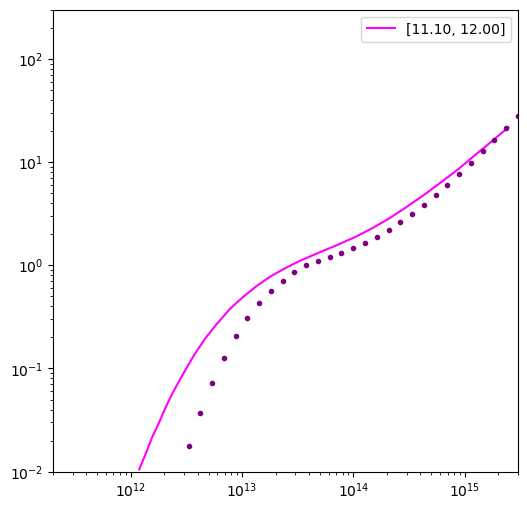

In [7]:
plt.figure(figsize=(6, 6))
plt.loglog(N1raw_x, N1raw_y, c='magenta', label='[11.10, 12.00]')

Ms = np.geomspace(2e10, 3e15)
plt.loglog(Ms, More2015(Ms, "A").N(), lw=0, marker='.', c='purple')

plt.xlim(2e11, 3*10**15), plt.ylim(1e-2, 3e2)
plt.legend()
plt.show()

In [ ]:
ms_cmass = 10**np.array([12.27689266, 12.67884686, 13.16053855, 13.69871423])
ws_cmass = np.array([4.13431979e-03, 1.31666601e-01, 3.36540698e-01, 8.13760167e-02])

In [ ]:
Ms = np.geomspace(1e12, 2e15, 1000)
plt.plot(Ms, Kou2023(Ms, "A").Nc(), c='orangered', lw=3, label=r"$\langle N_\text{cen} \rangle$")
plt.plot(Ms, Kou2023(Ms, "A", {'logM_min': 13}).Nc(), c='darkorange', lw=3, ls='--', label=r"Lower $M_\text{min}$")
plt.plot(Ms, Kou2023(Ms, "A", {'logM_min': 14}).Nc(), c='darkred', lw=3, ls='--', label=r"Higher $M_\text{min}$")
# 'logM_min': 12}
# plt.plot(Ms, Kou2023(Ms, "A").Ns(), c='dodgerblue', lw=3, label=r"$\langle N_\text{sat} | M \rangle$")
plt.xscale('log'), plt.ylim(-0.1, 1.1)
plt.xlabel(r"Halo Mass $M \ [M_\odot]$", fontsize=15), plt.ylabel(r"Expected # of Galaxies $\langle N | M \rangle$", fontsize=15)
plt.minorticks_on(), plt.tick_params(direction='in', which='both', right=True, top=True)
plt.grid(ls=':', alpha=0.5, c='k'), plt.legend(fontsize=15); plt.show()

In [ ]:
Ms = np.geomspace(1e12, 2e15, 1000)
plt.plot(Ms, Kou2023(Ms, "A").Ns(), c='dodgerblue', lw=3, label=r"$\langle N_\text{sat} \rangle$")
plt.plot(Ms, Kou2023(Ms, "A", {'logM_min': 13}).Ns(), c='darkturquoise', lw=3, ls='--', label=r"Lower $M_0$")
plt.plot(Ms, Kou2023(Ms, "A", {'logM_min': 14}).Ns(), c='darkblue', lw=3, ls='--', label=r"Higher $M_0$")
plt.xscale('log'), plt.yscale('log'), plt.ylim(1e-4, 1e2)
plt.xlabel(r"Halo Mass $M \ [M_\odot]$", fontsize=15), plt.ylabel(r"Expected # of Galaxies $\langle N | M \rangle$", fontsize=15)
plt.minorticks_on(), plt.tick_params(direction='in', which='both', right=True, top=True)
plt.grid(ls=':', alpha=0.5, c='k'), plt.legend(fontsize=15); plt.show()

In [ ]:
def satfrac(ms, logM1, subset):
    return np.trapezoid(Kou2023(ms, subset, override={"logM_1":logM1}).Ns(), ms) / \
            np.trapezoid(Kou2023(ms, subset, override={"logM_1":logM1}).N(), ms)

zs = np.array([0.55])
ks = np.geomspace(1e-4,100,101)
hcoscmass = hm.HaloModel(zs,ks,ms=ms_cmass)

def satfrac_cmassws(logM1s, subset):
    sfs = []
    for logM1 in logM1s:
        sfs.append(np.trapezoid(Kou2023(ms_cmass, subset, override={"logM_1":logM1}).Ns()*hcoscmass.nzm[0], ms_cmass) / \
                    np.trapezoid(ws_cmass*hcoscmass.nzm[0], ms_cmass))
    return np.array(sfs)


zs = np.array([0.55])
ks = np.geomspace(1e-4,100,101)
hcos = hm.HaloModel(zs,ks,ms=np.geomspace(ms_cmass[0],ms_cmass[-1],200))

def satfrac_hmvecws(logM1s, subset):
    sfs = []
    for logM1 in logM1s:
        sfs.append(np.trapezoid(Kou2023(hcos.ms, subset, override={"logM_1":logM1}).Ns()*hcos.nzm[0], hcos.ms) / \
                    np.trapezoid(Kou2023(hcos.ms, subset, override={"logM_1":logM1}).N()*hcos.nzm[0], hcos.ms))
    return np.array(sfs)

In [ ]:
M1s = np.geomspace(1e10, 1e15, 100)
plt.plot(M1s, satfrac_hmvecws(np.log10(M1s), "A"), label='hmvec')

plt.xlabel('Value of $M_1$'), plt.ylabel('Total Satellite Fraction')
plt.xscale('log')
plt.legend(); plt.show()

Customizing

In [ ]:
fig = plt.figure(figsize=(6, 4))

plt.ylabel(r'$\langle N | M \rangle$', fontsize=15), plt.ylim(5e-4, 3e1)

Ms = np.geomspace(1e10, 2e15)
plt.loglog(Ms, Kou2023(Ms, "A").N(), c='b', marker='.', lw=0, label=r'log$(M_\star/M_\odot)>10.8$')

override = {'logM_min': 12}
plt.loglog(Ms, Kou2023(Ms, "A", override=override).N(), c='magenta', marker='.', lw=0, label='override')

plt.loglog(M_Kou2023, NM_A_Kou2023)
plt.legend(fontsize=10)


plt.xlabel(r'M [M$_\odot$]', size=15), plt.xlim(1e12, 10**15.25)

plt.minorticks_on(), plt.tick_params(direction='in', which='both', right=True, top=True)
plt.show()

Putting into hmvec

In [ ]:
zs = np.linspace(0.,3.,20)
ms = np.geomspace(2e10,1e17,200)
ks = np.geomspace(1e-4,100,1001)
hcos = hm.HaloModel(zs,ks,ms=ms)

xmax = 25
nxs = 1000
hcos.add_battaglia_pres_profile("y",family='pres', xmax=xmax,nxs=nxs, ignore_existing=True)

HODModelA = Add_HOD(Kou2023(hcos.ms, "A"), hcos)
HODModelB = Add_HOD(Kou2023(hcos.ms, "B"), hcos)
HODModelC = Add_HOD(Kou2023(hcos.ms, "C"), hcos)
HODModelD = Add_HOD(Kou2023(hcos.ms, "D"), hcos)
HODModelA_alt = Add_HOD(Kou2023(hcos.ms, "A", override=override), hcos)


zind = 5

PgyA = hcos.get_power('y', HODModelA, verbose=False)[zind]
PgyB = hcos.get_power('y', HODModelB, verbose=False)[zind]
PgyC = hcos.get_power('y', HODModelC, verbose=False)[zind]
PgyD = hcos.get_power('y', HODModelD, verbose=False)[zind]
PgyA_alt = hcos.get_power('y', HODModelA_alt, verbose=False)[zind]

In [ ]:
fig, gs = plt.figure(figsize=(6, 4)), gridspec.GridSpec(2, 1, height_ratios=[3, 1]) 
fig.subplots_adjust(hspace=0), plt.yticks([]), plt.xticks([])
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1], sharex=ax1)

ax1.set_ylabel(r'P$^{gy}$', fontsize=15)
ax1.loglog(hcos.ks, PgyA, c='b', lw=1, label=r'log$(M_\star/M_\odot)>10.8$')
ax1.loglog(hcos.ks, PgyB, c='orange', lw=1, label=r'log$(M_\star/M_\odot)>11.1$')
ax1.loglog(hcos.ks, PgyC, c='green', lw=1, label=r'log$(M_\star/M_\odot)>11.25$')
ax1.loglog(hcos.ks, PgyD, c='r', lw=1, label=r'log$(M_\star/M_\odot)>11.4$')
ax1.loglog(hcos.ks, PgyD, c='magenta', lw=1, label=r'ALT log$(M_\star/M_\odot)>11.4$')
ax1.legend(fontsize=10)

ax2.set_ylabel(r'% $\Delta$', fontsize=10), ax2.set_ylim(-1.5, 1)
ax2.plot(hcos.ks, (PgyA-PgyA)/PgyA, c='b', lw=1)
ax2.plot(hcos.ks, (PgyA-PgyB)/PgyA, c='orange', lw=1)
ax2.plot(hcos.ks, (PgyA-PgyC)/PgyA, c='g', lw=1)
ax2.plot(hcos.ks, (PgyA-PgyD)/PgyA, c='r', lw=1)
ax2.plot(hcos.ks, (PgyA-PgyA_alt)/PgyA, c='magenta', lw=1)


plt.xlabel(r'k [Mpc$^{-1}$]', fontsize=15), plt.xlim(9e-3, 1.1e2)
ax1.minorticks_on(), ax1.tick_params(direction='in', which='both', right=True, top=True, labelbottom=False)
ax2.minorticks_on(), ax2.tick_params(direction='in', which='both', right=True, top=True)
plt.savefig(homepath+'Figures/'+'Test.png', dpi=200)